In [3]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('Chronic_Kidney_Dsease_data.csv')
# Basic view
print(df.head())

# Dataset info
print(df.info())

# Missing values
print(df.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'Chronic_Kidney_Dsease_data.csv'

In [ ]:
target_col = df.columns[-1]
print("Target Column:", target_col)

Target Column: DoctorInCharge


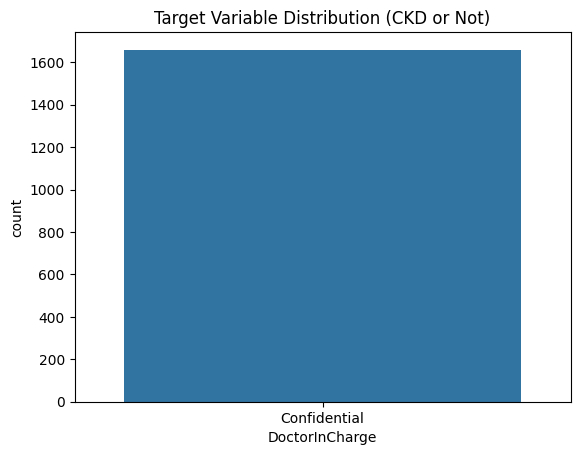

In [ ]:
plt.figure()
sns.countplot(x=df[target_col])
plt.title("Target Variable Distribution (CKD or Not)")
plt.show()

In [ ]:
df.replace('?', np.nan, inplace=True)
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
SocioeconomicStatus,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0


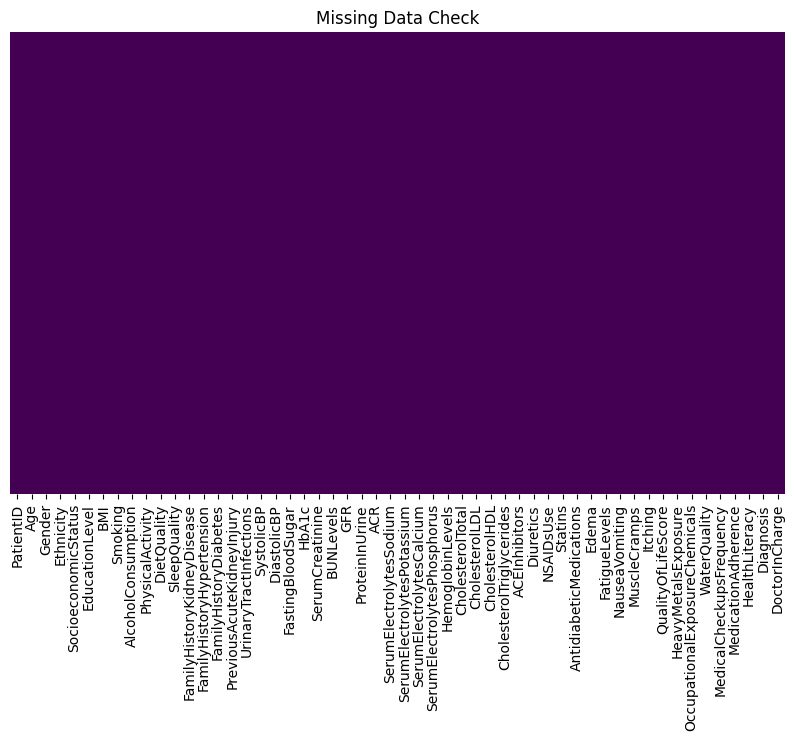

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Check")
plt.show()

Step 1: Target Variable Check (Graph 1)**bold text**

/tmp/ipykernel_6187/1181821649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='viridis')


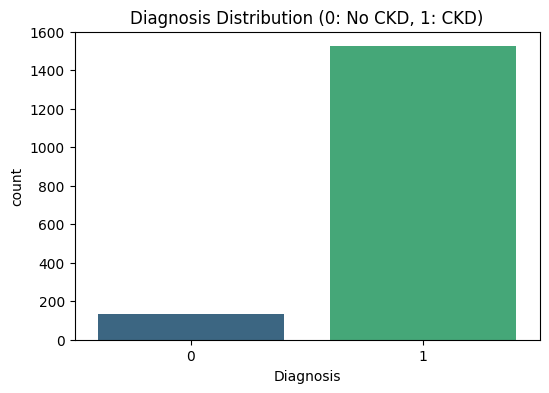

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=df, palette='viridis')
plt.title('Diagnosis Distribution (0: No CKD, 1: CKD)')
plt.show()

**Step 2: Correlation Analysis (Graph 2)**

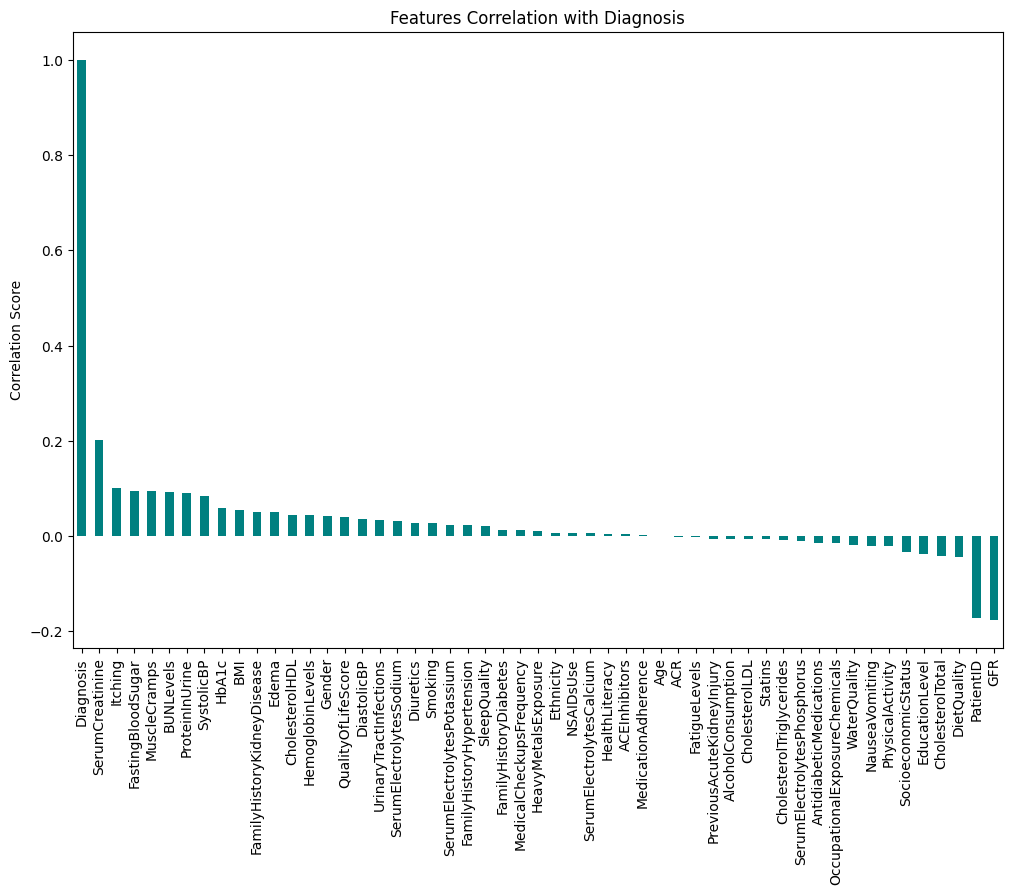

In [ ]:
plt.figure(figsize=(12,8))

# Pehle sirf numbers wale columns select karo (Text columns nikal do)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Ab correlation nikalo
numeric_df.corr()['Diagnosis'].sort_values(ascending=False).plot(kind='bar', color='teal')

plt.title('Features Correlation with Diagnosis')
plt.ylabel('Correlation Score')
plt.show()

**Step 3: Distribution of Key Features (Graph 3)**

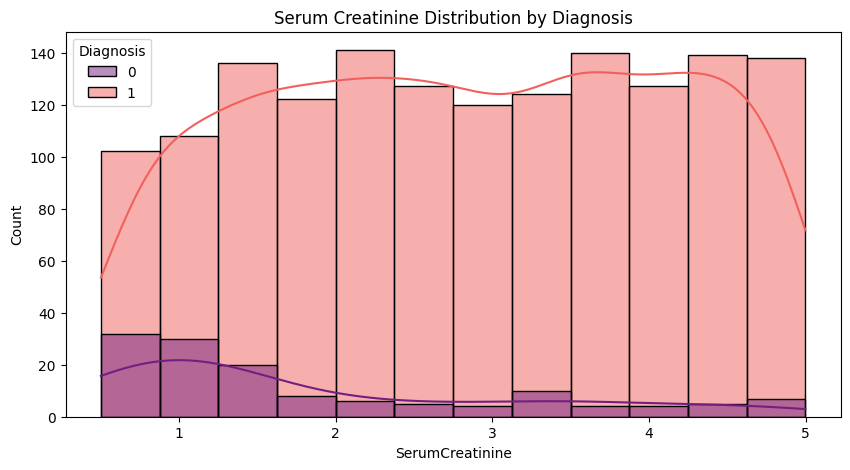

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='SerumCreatinine', hue='Diagnosis', kde=True, palette='magma')
plt.title('Serum Creatinine Distribution by Diagnosis')
plt.show()

**Step 4: Outlier Detection (Graph 4)**

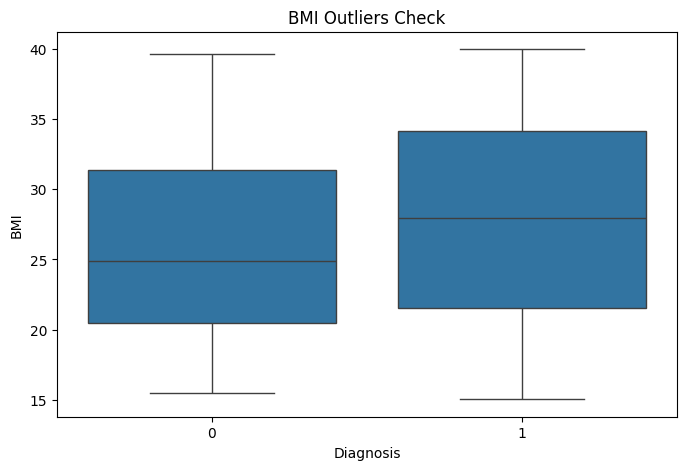

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Diagnosis', y='BMI', data=df)
plt.title('BMI Outliers Check')
plt.show()

**Step 5: Final Preparation (Encoding & Splitting)**

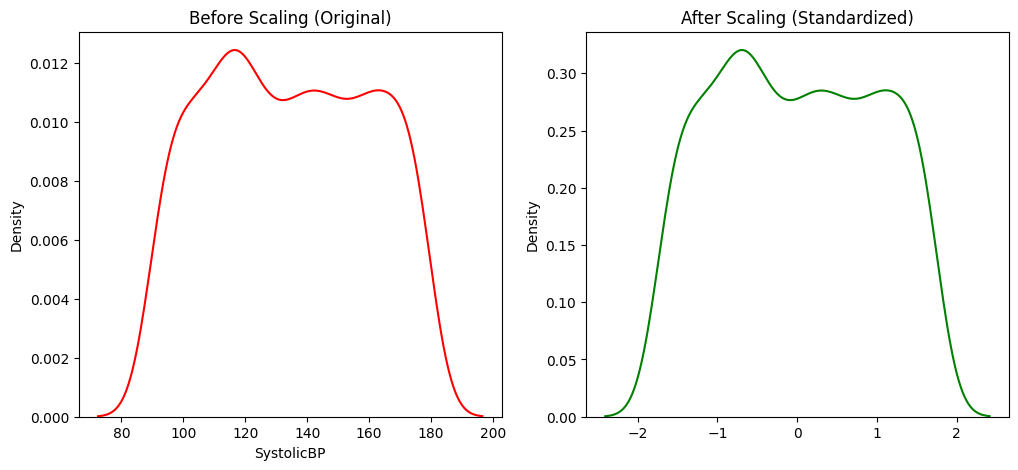

preprocessing Complete !.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Aik sample feature letay hain jaise 'SystolicBP'
original_data = df[['SystolicBP']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(original_data)

# Graph banatay hain comparison ke liye
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling (Original)')
sns.kdeplot(df['SystolicBP'], ax=ax1, color='red')

ax2.set_title('After Scaling (Standardized)')
sns.kdeplot(scaled_data.flatten(), ax=ax2, color='green')

plt.show()
print("preprocessing Complete !.")

**Feature Extraction**

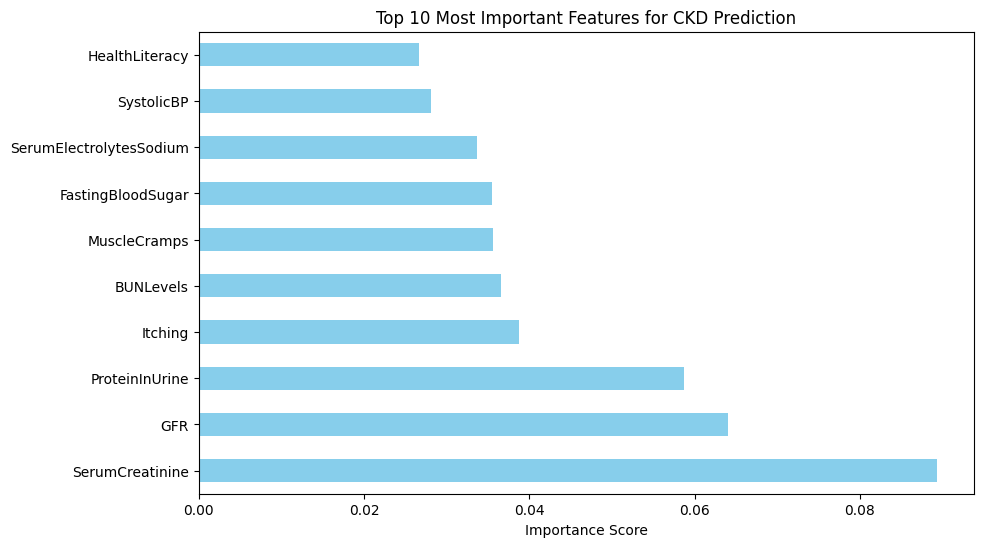

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sirf numerical data select karein
X = df.drop(['Diagnosis', 'PatientID', 'DoctorInCharge'], axis=1)
y = df['Diagnosis']

# 2. Model ko use karke feature importance nikaalna
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Importances ko dataframe mein daalna
feat_importances = pd.Series(model.feature_importances_, index=X.columns)

# 4. Top 10 features ka graph
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Important Features for CKD Prediction')
plt.xlabel('Importance Score')
plt.show()

**1. Confusion Matrix Heatmap**

<Figure size 800x600 with 0 Axes>

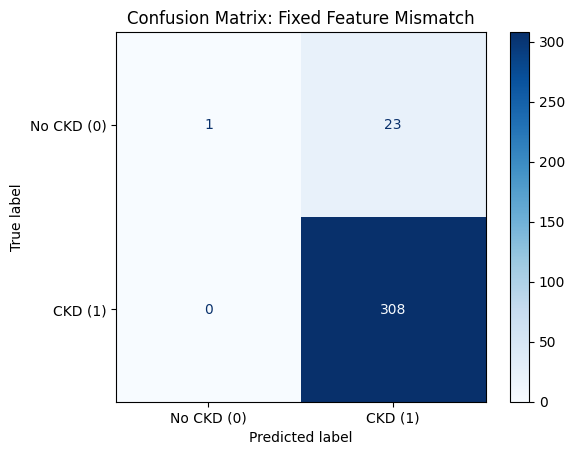

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Features (X) aur Target (y) alag karein
# Hum 3 columns nikal rahe hain: Diagnosis (Target), PatientID (ID), DoctorInCharge (Text)
# Total 54 columns thay, 3 nikal kar 51 bachne chahiye
X = df.drop(['Diagnosis', 'PatientID', 'DoctorInCharge'], axis=1)
y = df['Diagnosis']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Dono sets par aik hi scaler apply karein)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Model Prediction (Ab features 51 hi honge)
predictions = model.predict(X_test_scaled)

# 6. Confusion Matrix Plot
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CKD (0)', 'CKD (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Fixed Feature Mismatch')
plt.show()

**Model  Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier  # <--- KNN ko import kiya
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Models ko initialize karna (Ab total 5 models ho gaye hain)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)  # <--- KNN ko standard 5 neighbors ke sath add kiya
}

# 2. Training Loop
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train) # Model ko sikhana
    trained_models[name] = model
    print(f"{name} trained successfully!")


Logistic Regression trained successfully!
Random Forest trained successfully!
SVM trained successfully!
Gradient Boosting trained successfully!
KNN trained successfully!


**Step 2: Prediction & Initial Accuracy**

In [ ]:
#  Accuracy compare karne ke liye dictionary
accuracy_results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Results ko table ki shakal mein dekhna
results_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])
print("\n--- Final Model Comparison ---")
print(results_df.sort_values(by='Accuracy', ascending=False).to_string(index=False))


Logistic Regression Accuracy: 0.9367
Random Forest Accuracy: 0.9307
SVM Accuracy: 0.9277
Gradient Boosting Accuracy: 0.9337
KNN Accuracy: 0.9187

--- Final Model Comparison ---
              Model  Accuracy
Logistic Regression  0.936747
  Gradient Boosting  0.933735
      Random Forest  0.930723
                SVM  0.927711
                KNN  0.918675


**Step 3: Visualization of Training (Graph)**

/tmp/ipykernel_6187/554665039.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values(by='Accuracy', ascending=False), palette='magma')


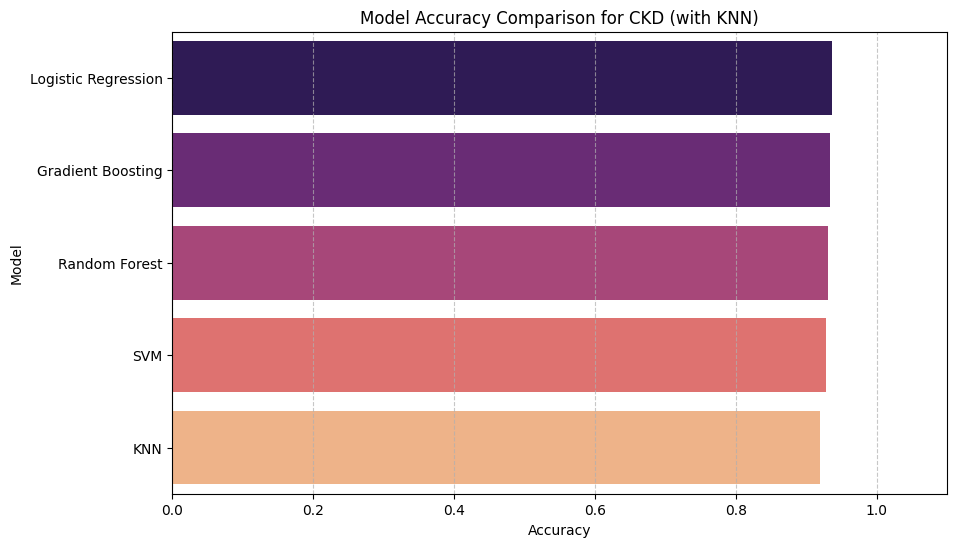

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# VISUALIZATION PART: ACCURACY COMPARISON GRAPH
# =========================================================
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values(by='Accuracy', ascending=False), palette='magma')
plt.title('Model Accuracy Comparison for CKD (with KNN)')
plt.xlim(0, 1.1) # Scale 0 se 1.1 tak
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# =========================================================
# EXTRA STEP: PROFESSIONAL COMPARISON TABLE
# =========================================================

# Results ko descending order (highest to lowest) mein sort karna
sorted_results = results_df.sort_values(by='Accuracy', ascending=False).copy()

# Accuracy ko percentage (%) mein badalna taake report mein achi lage
sorted_results['Accuracy (%)'] = (sorted_results['Accuracy'] * 100).round(2).astype(str) + '%'

# Final table formatting (Sirf Model aur Percentage columns dikhane ke liye)
final_table = sorted_results[['Model', 'Accuracy (%)']].reset_index(drop=True)

# Colab mein khoobsurat display ke liye style apply karna
print("--- Professional Model Performance Table ---")
display(final_table)

--- Professional Model Performance Table ---


,Model,Accuracy (%)
0,Logistic Regression,93.67%
1,Gradient Boosting,93.37%
2,Random Forest,93.07%
3,SVM,92.77%


**Model Evaluation Metrics (Precision, Recall, ROC Curve)**

Evaluating the Best Model: Logistic Regression

   CLASSIFICATION REPORT (Logistic Regression)
              precision    recall  f1-score   support

           0       0.71      0.21      0.32        24
           1       0.94      0.99      0.97       308

    accuracy                           0.94       332
   macro avg       0.83      0.60      0.64       332
weighted avg       0.93      0.94      0.92       332

ROC-AUC Score: 0.8254



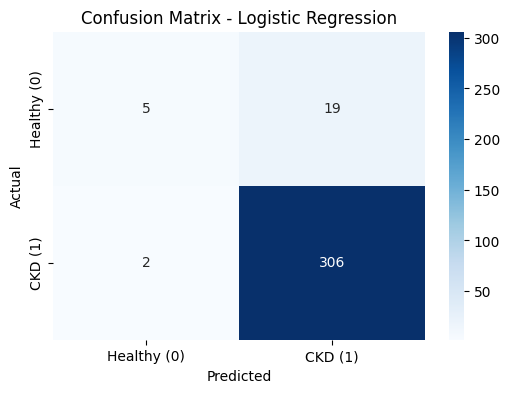

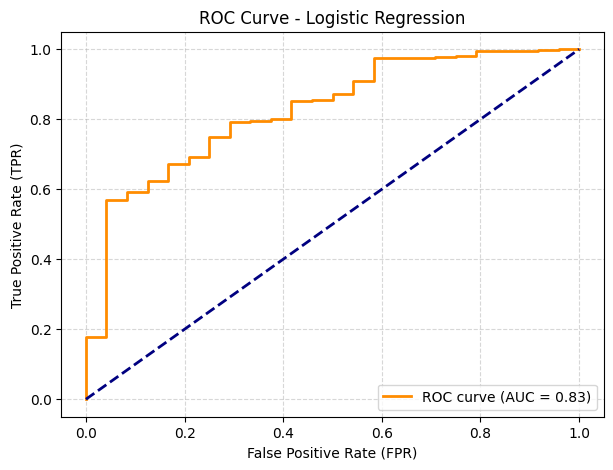

In [ ]:
# =========================================================
# : DETAILED EVALUATION METRICS (CLASSIFICATION METRICS)
# =========================================================
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

# Hum automatically best performing model select kar rahe hain evaluation ke liye
best_model_name = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Evaluating the Best Model: {best_model_name}\n")

# Predictions aur probabilities nikalna
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print("="*40)
print(f"   CLASSIFICATION REPORT ({best_model_name})")
print("="*40)
print(classification_report(y_test, y_pred_best))

auc_best = roc_auc_score(y_test, y_prob_best)
print(f"ROC-AUC Score: {auc_best:.4f}")
print("="*40 + "\n")

# Graphs: Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'CKD (1)'],
            yticklabels=['Healthy (0)', 'CKD (1)'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Graphs: ROC Curve
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(7, 5))
plt.plot(fpr_best, tpr_best, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_best:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title(f'ROC Curve - {best_model_name}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**FEATURE IMPORTANCE (DIRECT RANDOM FOREST)**

Extracting feature importances from Random Forest...


/tmp/ipykernel_6187/1581514232.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')


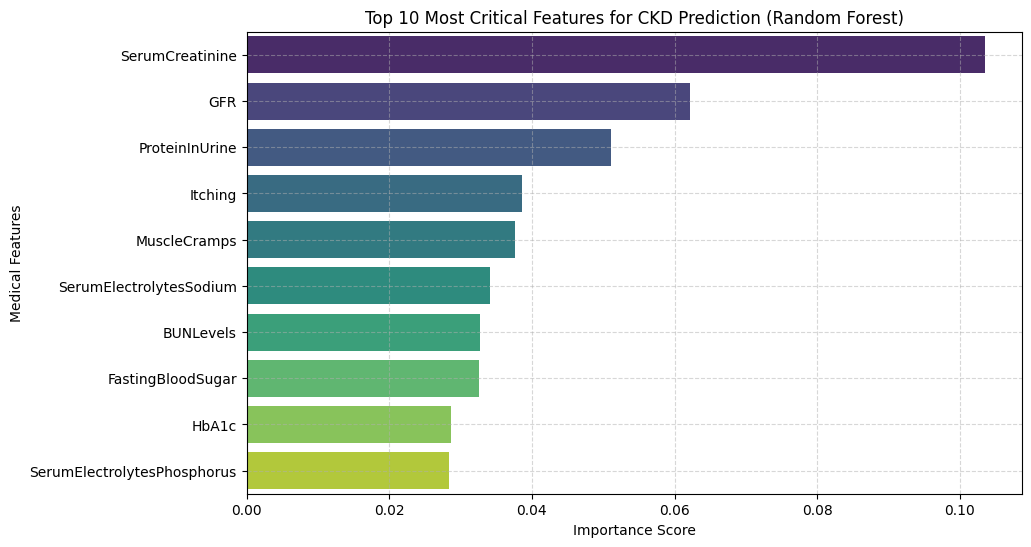


--- Top 5 Most Important Biomarkers ---
        Feature  Importance
SerumCreatinine    0.103467
            GFR    0.062198
 ProteinInUrine    0.051159
        Itching    0.038599
   MuscleCramps    0.037577


In [ ]:
# =========================================================
#  FEATURE IMPORTANCE (DIRECT RANDOM FOREST)
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting feature importances from Random Forest...")

# Hum direct trained_models se Random Forest ko utha rahe hain
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

# DataFrame bana kar sort karna
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 10 Features ka Horizontal Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Critical Features for CKD Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Medical Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\n--- Top 5 Most Important Biomarkers ---")
print(feat_imp_df.head(5).to_string(index=False))